In [1]:
# Some utitity libraries to test optuna
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Optuna is the library used for hyperparameter estimation based on many samplers.
# Mostly we use a sampler called TPE.
# Now this notebook is a complete walkthrough on why do we need optuna ? How did it come to existence ?
# Why other sampling methods failed ? 
# This notebook is not just about simply implement optuna -- It is about comprehending it's need.

In [3]:
# Way before we had no such things as optimizer . All we had  was intutive guessing and manual looping over different hyperparameters.
# This was manual tuning .The code block would look like: 

In [4]:
# A simple iris dataset 
X,y = load_iris(return_X_y=True)

# Divide the data into three set of data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
X_test,X_val,y_test,y_val = train_test_split(X_test,y_test,test_size=0.5,random_state=42)

In [5]:
depths = [2,3,4,5,6,7,8]

best_score = -1
best_depth = None

for depth in depths:

    model = RandomForestClassifier(max_depth=depth)

    model.fit(X_train, y_train)

    score = model.score(X_val, y_val)

    print(f"Depth : {depth} | Score : {score}")

    if score > best_score:
        best_score = score
        best_depth = depth

print(best_depth)

# NOTE : This is codeblock is not to be evaluated but instead it showcases the manual hardship we had to do get the perfect the parameter.
# The dataset is too simple and model can easily learn all the patterns.

Depth : 2 | Score : 1.0
Depth : 3 | Score : 1.0
Depth : 4 | Score : 1.0
Depth : 5 | Score : 1.0
Depth : 6 | Score : 1.0
Depth : 7 | Score : 1.0
Depth : 8 | Score : 1.0
2


In [6]:
# This was just a few depths and also one parameter .
# Now imagine big data , 100 of parameters and wait we have not talked about the combinations of each parameter yet.
# Multiple nested loops , memory hell and infinite-like time --- This is what we had to deal with for many years.

# We could have guessed parameters but there is a limit to the intutive guessing.
# Our function is basically: 

# From its perspective, it is solving        :   f(hyperparameters) → validation score
# The entire optimisation problem is simply  :   Find the hyperparameters that maximise (or minimise) this unknown function.

In [7]:
X, y = load_iris(return_X_y=True)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# BLACK BOX: THE EVALUATION ALGORITHM
# ==========================================
def evaluate(algorithm,params, X_data, y_data):
    """
    Acts as the black-box abstraction: f(hyperparameters) -> average validation score.
    The training algorithm (Random Forest) stays completely isolated inside here.
    It has no idea it is being searched or optimized.
    Please Make sure to pass the algorithm object not the function.
    """

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_scores = []
    
    for train_idx, val_idx in kf.split(X_data):
        X_train, X_val = X_data[train_idx], X_data[val_idx]
        y_train, y_val = y_data[train_idx], y_data[val_idx]
        
        model = algorithm(**params, random_state=42)
        model.fit(X_train, y_train)
        
        score = model.score(X_val, y_val)
        fold_scores.append(score)
        
    return np.mean(fold_scores)


# ==========================================
# THE SEARCH ALGORITHM (Grid Search)
# ==========================================

param_grid = {
    'n_estimators':[50,100,125],
    'max_depth': [3, 5, None]
}


num_n_est = len(param_grid['n_estimators'])
num_depths = len(param_grid['max_depth'])
total_experiments = num_n_est * num_depths
folds = 3

print("--- COMPUTATIONAL COST ANALYSIS ---")
print(f"Hyperparameter 1 (n_estimators): {num_n_est} values")
print(f"Hyperparameter 2 (max_depth): {num_depths} values")
print(f"Total Unique Configurations: {num_n_est} × {num_depths} = {total_experiments} combinations")
print(f"Total Model Fits Required: {total_experiments} configs × {folds} CV folds = {total_experiments * folds} total runs")
print("-----------------------------------\n")

best_score = 0
best_params = {}

print("--- RUNNING GRID SEARCH ALGORITHM ---")

for n_est in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:

        current_params = {'n_estimators': n_est, 'max_depth': depth}
        avg_cv_score = evaluate(RandomForestClassifier,current_params, X_train_val, y_train_val)
        print(f"Testing Config: {current_params} | Result (Avg CV Score): {avg_cv_score:.4f}")
        
        if avg_cv_score > best_score:
            best_score = avg_cv_score
            best_params = current_params

print("\n--- SEARCH COMPLETE ---")

print(f"Optimal Hyperparameters: {best_params} with Best Avg CV Score: {best_score:.4f}")


best_model = RandomForestClassifier(**best_params, random_state=42)
best_model.fit(X_train_val, y_train_val)

final_test_score = best_model.score(X_test, y_test)
print(f"Best Test Score: {final_test_score:.4f}")


--- COMPUTATIONAL COST ANALYSIS ---
Hyperparameter 1 (n_estimators): 3 values
Hyperparameter 2 (max_depth): 3 values
Total Unique Configurations: 3 × 3 = 9 combinations
Total Model Fits Required: 9 configs × 3 CV folds = 27 total runs
-----------------------------------

--- RUNNING GRID SEARCH ALGORITHM ---
Testing Config: {'n_estimators': 50, 'max_depth': 3} | Result (Avg CV Score): 0.9667
Testing Config: {'n_estimators': 50, 'max_depth': 5} | Result (Avg CV Score): 0.9500
Testing Config: {'n_estimators': 50, 'max_depth': None} | Result (Avg CV Score): 0.9500
Testing Config: {'n_estimators': 100, 'max_depth': 3} | Result (Avg CV Score): 0.9667
Testing Config: {'n_estimators': 100, 'max_depth': 5} | Result (Avg CV Score): 0.9583
Testing Config: {'n_estimators': 100, 'max_depth': None} | Result (Avg CV Score): 0.9583
Testing Config: {'n_estimators': 125, 'max_depth': 3} | Result (Avg CV Score): 0.9667
Testing Config: {'n_estimators': 125, 'max_depth': 5} | Result (Avg CV Score): 0.9583

In [8]:
# This is a simple hardcoded working of how gridsearch csv works behind the scenes.
# Look closely how we working a grid like pattern : 
#   First we go on with first parameters and keep on looping till all the nested loop combinations are finished ,
#    exiting and going on to another outer loop and so on.

In [9]:
# Actually every combinations is the cartesian product of the parameters.
# Also we have a tool that gives us the cartesian product of all the combinations 
# So a better can be : 

In [10]:
from itertools import product # This library gives us the cartesian product (every combination)

# For example : 
param_grid = {
    'n_estimators':[50,100,125],
    'max_depth': [3, 5, None]
}
for x in product(*param_grid.values()):
    print(x)


(50, 3)
(50, 5)
(50, None)
(100, 3)
(100, 5)
(100, None)
(125, 3)
(125, 5)
(125, None)


In [11]:
# This is exactly what we wanted to further optimize our gridsearch

In [12]:
# Improvised version of our gridsearch : 
X, y = load_iris(return_X_y=True)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# BLACK BOX: THE EVALUATION ALGORITHM
# ==========================================
def evaluate(algorithm,params, X_data, y_data):
    """
    Acts as the black-box abstraction: f(hyperparameters) -> average validation score.
    The training algorithm (Random Forest) stays completely isolated inside here.
    It has no idea it is being searched or optimized.
    Please Make sure to pass the algorithm object not the function.
    """

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_scores = []
    
    for train_idx, val_idx in kf.split(X_data):
        X_train, X_val = X_data[train_idx], X_data[val_idx]
        y_train, y_val = y_data[train_idx], y_data[val_idx]
        
        model = algorithm(**params, random_state=42)
        model.fit(X_train, y_train)
        
        score = model.score(X_val, y_val)
        fold_scores.append(score)
        
    return np.mean(fold_scores)


# ==========================================
# THE SEARCH ALGORITHM (Grid Search)
# ==========================================

param_grid = {
    'n_estimators':[50,100,125],
    'max_depth': [3, 5, None]
}


num_n_est = len(param_grid['n_estimators'])
num_depths = len(param_grid['max_depth'])
total_experiments = num_n_est * num_depths
folds = 3

print("--- COMPUTATIONAL COST ANALYSIS ---")
print(f"Hyperparameter 1 (n_estimators): {num_n_est} values")
print(f"Hyperparameter 2 (max_depth): {num_depths} values")
print(f"Total Unique Configurations: {num_n_est} × {num_depths} = {total_experiments} combinations")
print(f"Total Model Fits Required: {total_experiments} configs × {folds} CV folds = {total_experiments * folds} total runs")
print("-----------------------------------\n")

best_score = 0
best_params = {}

print("--- RUNNING GRID SEARCH ALGORITHM ---")

params = list(param_grid.keys())

for values in product(*param_grid.values()):
    
    current_params = dict(zip(params,values))
    avg_cv_score = evaluate(RandomForestClassifier,current_params, X_train_val, y_train_val)
    print(f"Testing Config: {current_params} | Result (Avg CV Score): {avg_cv_score:.4f}")
        
    if avg_cv_score > best_score:
            best_score = avg_cv_score
            best_params = current_params

print("\n--- SEARCH COMPLETE ---")

print(f"Optimal Hyperparameters: {best_params} with Best Avg CV Score: {best_score:.4f}")


best_model = RandomForestClassifier(**best_params, random_state=42)
best_model.fit(X_train_val, y_train_val)

final_test_score = best_model.score(X_test, y_test)
print(f"Best Test Score: {final_test_score:.4f}")


--- COMPUTATIONAL COST ANALYSIS ---
Hyperparameter 1 (n_estimators): 3 values
Hyperparameter 2 (max_depth): 3 values
Total Unique Configurations: 3 × 3 = 9 combinations
Total Model Fits Required: 9 configs × 3 CV folds = 27 total runs
-----------------------------------

--- RUNNING GRID SEARCH ALGORITHM ---
Testing Config: {'n_estimators': 50, 'max_depth': 3} | Result (Avg CV Score): 0.9667
Testing Config: {'n_estimators': 50, 'max_depth': 5} | Result (Avg CV Score): 0.9500
Testing Config: {'n_estimators': 50, 'max_depth': None} | Result (Avg CV Score): 0.9500
Testing Config: {'n_estimators': 100, 'max_depth': 3} | Result (Avg CV Score): 0.9667
Testing Config: {'n_estimators': 100, 'max_depth': 5} | Result (Avg CV Score): 0.9583
Testing Config: {'n_estimators': 100, 'max_depth': None} | Result (Avg CV Score): 0.9583
Testing Config: {'n_estimators': 125, 'max_depth': 3} | Result (Avg CV Score): 0.9667
Testing Config: {'n_estimators': 125, 'max_depth': 5} | Result (Avg CV Score): 0.9583

# The similarities and difference between ManualTuning and GridSeachCV
------------------------------
## The Similarity (The Logic)
Both methods do the exact same work behind the scenes:

   1. They take a dictionary of hyperparameters.
   2. They map out every single possible combination (the "grid").
   3. They run cross-validation loops for every combination.
   4. They pick the combination with the highest average validation score. [3, 4, 5, 6, 7] 

------------------------------
## The Differences (The Execution)

| Feature | Manual Tuning (Your Loop Code) | Scikit-Learn's GridSearchCV |
|---|---|---|
| Code Length | Requires 30+ lines of nested loops and index tracking. | Requires only 3 to 4 lines of clean code. |
| Error Proneness | Easy to accidentally leak data or mess up index slicing. | Robust and thoroughly tested to prevent bugs. |
| Speed (Parallelization) | Runs on a single CPU core sequentially (slow). | Can run on all CPU cores at once using n_jobs=-1 (very fast). |
| Refitting | You must manually write code to retrain the model on the full data at the end. | Automatically retrains the best model for you (refit=True). |

------------------------------


In [13]:
# NOTE :  We did not import the GridSearchCV of the scikit-learn , which is much more robust.

## The Structural Flaws of Grid Search

* Zero Memory: It treats every single experiment as a completely isolated event.
* Refusal to Learn: It completely forgets the results of Experiment #1 before running Experiment #2.
* Wasted Labor: It forces the computer to finish testing poor configurations (like bad tea brands) even when early results prove they are failures.
* Static Beliefs: It cannot use trends from successful runs (like seeing accuracy jump at a certain depth) to narrow its focus on the "sweet spot."

## The Pivot to Random Search

* The Random Alternative: Instead of a rigid, systematic walk across a grid, it randomly throws darts at the search space.
* Surprisingly Better: It sounds chaotic, but mathematically, random guessing frequently beats a structured grid.
* Geometry over Rigidity: It avoids the trap of wasting time on unimportant parameters, setting the stage for the next breakthrough in optimization history.




In [14]:
# Random Search is pure madness
# It is just simply throwing random darts at our grid search space grid and only evaluating that subset only .
"""
Grid Search assumes

    Every hyperparameter deserves equal attention.

Reality says

    Some hyperparameters dominate the model, while others have only a minor effect.

Instead of searching every point in grid search upto a subsample limit.

Is RandomSearchActually better than GridSearchCV when only a small subset of parameters influence the model peformance ? YES !!!

"""


'\nGrid Search assumes\n\n    Every hyperparameter deserves equal attention.\n\nReality says\n\n    Some hyperparameters dominate the model, while others have only a minor effect.\n\nInstead of searching every point in grid search upto a subsample limit.\n\nIs RandomSearchActually better than GridSearchCV when only a small subset of parameters influence the model peformance ? YES !!!\n\n'


## Why Random Search Can Outperform Grid Search
Let's use a simple analogy to understand the intuition behind this concept.
## The Problem

Imagine you are searching for buried treasure on a 100 m × 100 m beach. However, the treasure is buried somewhere along a single, narrow line. This means only one specific coordinate (dimension) actually matters for finding it.

------------------------------
## Method 1: Grid Search
Grid Search walks the beach in neat, rigid rows.

      □  □  □  □  □  □
      □  □  □  □  □  □
      □  □  □  □  □  □
      □  □  □  □  □  □


* The Flaw: Because it repeats the same coordinates across different rows, it tests very few unique values along that one critical dimension.

------------------------------
## Method 2: Random Search
Random Search drops 100 random pins across the beach.

      •      •       •
      •       •
      •       •      •
            •       •


* The Advantage: Because the pins are placed randomly, every single point tests a completely unique value along the important coordinate.
* The Result: It covers the critical search space much more efficiently than a rigid grid.

------------------------------
## Summary
> This is the core intuition from the foundational paper on hyperparameter optimization: when only a few hyperparameters significantly impact model performance (low effective dimensionality), Random Search explores unique configurations faster and more effectively than Grid Search.


In [15]:
# If we had to implement this what we would do is use the random method to choose random susbsets from : product(param_grid.values())
# Then we would randomly assing value to the parameters and search instead of grid search

In [16]:
# THE NEXT IDEA is if we already get the best params after randomly searching , should the next search be also random ?
# Cause we already know the parameteric values for which the model performs good now -- what should we do next ?

In [17]:
"""
* Black Box Problem: Optimization is blind because hyperparameters like depth or categorical variables lack continuous gradients, 
     meaning standard calculus and gradient descent cannot be used.

* Surrogate Models: Instead of wasting hours training the real model for every guess, the optimizer builds a fast,
     mathematical "fake map" (surrogate model) to estimate performance based on past results.

* Uncertainty Quantification: The surrogate model tracks both the estimated score and how unsure it is about untested regions,
     creating a map of knowns and unknowns.

* Exploitation vs. Exploration: Using the uncertainty map, the optimizer intelligently decides 
     whether to search near proven high scores (exploit) or risk searching wide blind spots for hidden peaks (explore).
     
* Two Core Frameworks: History split into Gaussian Processes, which map smooth curves with growing uncertainty clouds, 
     and TPE (Optuna's default), which splits past trials into "Good" and "Bad" piles to quickly find winning parameters.
"""

'\n* Black Box Problem: Optimization is blind because hyperparameters like depth or categorical variables lack continuous gradients, \n     meaning standard calculus and gradient descent cannot be used.\n\n* Surrogate Models: Instead of wasting hours training the real model for every guess, the optimizer builds a fast,\n     mathematical "fake map" (surrogate model) to estimate performance based on past results.\n\n* Uncertainty Quantification: The surrogate model tracks both the estimated score and how unsure it is about untested regions,\n     creating a map of knowns and unknowns.\n\n* Exploitation vs. Exploration: Using the uncertainty map, the optimizer intelligently decides \n     whether to search near proven high scores (exploit) or risk searching wide blind spots for hidden peaks (explore).\n\n* Two Core Frameworks: History split into Gaussian Processes, which map smooth curves with growing uncertainty clouds, \n     and TPE (Optuna\'s default), which splits past trials into "

In [18]:
# So in simple words we try to map a surrogate model to make estimations based on our preexistence belief and try to find the best parameters of the real objective function.
""" 
                 Unknown Reality
                      │
                      │
          (Very expensive to evaluate)
                      │
                      ▼
        Real Objective Function
      f(hyperparameters) = CV Score
                      ▲
                      │
          We only observe a few points
                      │
      ┌───────────────┴───────────────┐
      │                               │
      ▼                               │
 Build Surrogate Model                │
  (Our current belief)                │
      │                               │
      ▼                               │
 Suggest Next Experiment ─────────────┘
"""

' \n                 Unknown Reality\n                      │\n                      │\n          (Very expensive to evaluate)\n                      │\n                      ▼\n        Real Objective Function\n      f(hyperparameters) = CV Score\n                      ▲\n                      │\n          We only observe a few points\n                      │\n      ┌───────────────┴───────────────┐\n      │                               │\n      ▼                               │\n Build Surrogate Model                │\n  (Our current belief)                │\n      │                               │\n      ▼                               │\n Suggest Next Experiment ─────────────┘\n'

## 1. How a Gaussian Process (GP) Thinks

* Continuous Map: Estimates predicted values and uncertainty levels for every potential point in the search space.
* Proximity Confidence: Uncertainty stays low near tested points and grows high in untested areas.
* The Analogy: Like predicting traffic, it has high confidence for busy highways but low confidence for empty mountain roads.

## 2. Exploration vs. Exploitation

* The Dilemma: Algorithms must balance two competing strategies to find the absolute best setup.
* Exploitation: Targets areas with known high performance to maximize short-term gains.
* Exploration: Targets untested territory with high uncertainty to potentially discover hidden peaks.


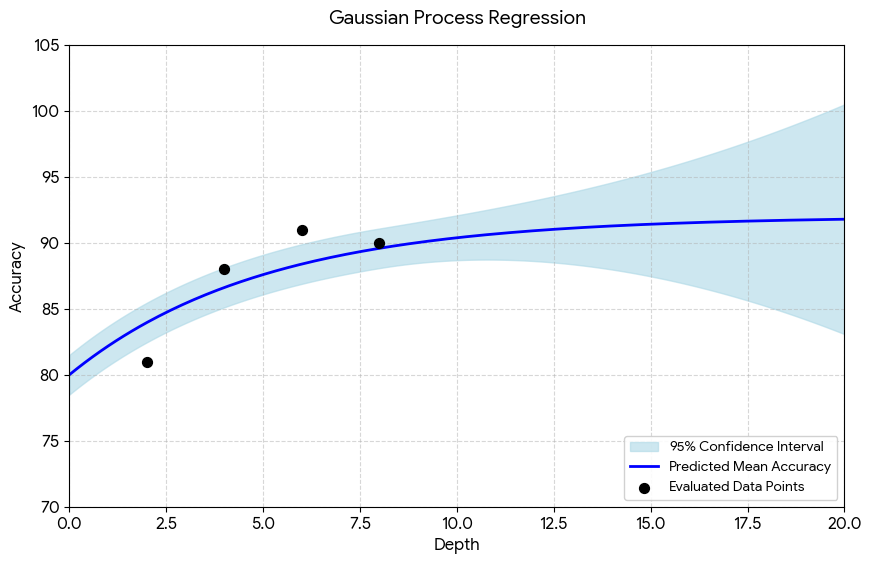

In [19]:
# So basically our gaussian process can calculate the mean and the confifdence invterval (confidence) for each point but which point to choose ?
# So basically we need to make a decision between exploring in the range of evaluated data points or infer the points far away which are unexplored.
# Schematically it looks like : 
""" 
             Gaussian Process
                     │
                     ▼
      Mean + Uncertainty for every point
                     │
                     ▼
        ??? Which point do we choose?
"""
# We have a seperate function to make this decision called the Acquisition function.


' \n             Gaussian Process\n                     │\n                     ▼\n      Mean + Uncertainty for every point\n                     │\n                     ▼\n        ??? Which point do we choose?\n'

# Bayesian Optimization: A Deep Dive

## 1. What is an Acquisition Function? (The Referee)

The **Gaussian Process (GP)** acts as the **"Brain."** It analyzes past experiments to predict two metrics for every possible parameter setting:

*   **The Mean ($\mu$):** Expected performance (e.g., *"I think the accuracy here will be 90%."*)
*   **The Uncertainty ($\sigma$):** Degree of doubt (e.g., *"But I am $\pm$8% unsure because we haven't tested near here."*)

The **Acquisition Function** acts as the **"Decision Maker."** It collapses the raw data (Mean + Uncertainty) into a single **Value Score**. 

Instead of calculating actual expected accuracy, it answers a strategic question: *"How much will we learn or benefit if we spend our next expensive experiment on this specific setting?"*

---

## 2. Step-by-Step Calculation: Upper Confidence Bound (UCB)

The Upper Confidence Bound formula highlights this mechanism:

$$\text{Score} = \mu(x) + \kappa \cdot \sigma(x)$$

### Scenario Setup
*   **Goal:** Tune a model's `max_depth` parameter.
*   **Constraint:** Limited budget requires picking between two settings for the next experiment.
*   **Risk-Appetite Knob ($\kappa$):** Set to $2$ (moderate preference for exploration).

### Candidate A: Depth = 5 (The Safe Bet)
*   **GP Prediction ($\mu$):** 91% accuracy.
*   **GP Uncertainty ($\sigma$):** 1% (Highly confident because nearby depths 4 and 6 were already tested).
*   **Calculation:**
    $$\text{Score} = 91 + (2 \times 1) = 93$$

### Candidate B: Depth = 20 (The Wild Card)
*   **GP Prediction ($\mu$):** 84% accuracy (The brain guesses lower performance due to overfitting risks in deeper trees).
*   **GP Uncertainty ($\sigma$):** 8% (Completely unchartered territory; no tests run above depth 8).
*   **Calculation:**
    $$\text{Score} = 84 + (2 \times 8) = 84 + 16 = 100$$

### The Decision
The Acquisition Function compares the scores: **Candidate B (100) > Candidate A (93)**.

Even though the system expects higher baseline accuracy from Depth 5, it forces a test on **Depth 20**. The massive uncertainty implies a realistic statistical chance that Depth 20 is a hidden goldmine. If it performs poorly, the local uncertainty drops to zero, and the algorithm shifts focus elsewhere.

---

## 3. Weaknesses of Gaussian-Process-Based Bayesian Optimization

Libraries like **Optuna** bypass Gaussian Processes by default due to several architectural limitations:

*   **Computational Bottleneck ($O(N^3)$ Complexity):** Every new experimental result forces the GP to invert a massive mathematical matrix. At 1,000+ trials, the algorithm spends more time calculating the next step than it takes to train the underlying AI model.
*   **The Curse of Dimensionality:** Performance degrades when scaling past 2 or 3 parameters. Tuning 20 parameters simultaneously creates an exponential search void, preventing meaningful uncertainty calculations.
*   **Categorical Data Friction:** GPs rely on distance mathematics (e.g., knowing depth 5 is close to depth 6). They cannot natively calculate mathematical distance between categorical choices like `["gbtree", "dart", "gblinear"]`.
*   **Conditional Parameter Failures:** GPs struggle with complex `if-this-then-that` logical trees. For instance, if `booster="gblinear"`, the parameter `max_depth` completely ceases to exist.


In [20]:
# So in simple words we use kappa to choose between ecploration and exploitation.
# This works for small datasets with only continous value and .
# These conditions are almost not satisified in real world leading to discovery of TPE.

In [21]:
# TPE : Tree-structured Parzen Estimator (TPE)

| Gaussian Process                         | TPE                                                                            |
| ---------------------------------------- | ------------------------------------------------------------------------------ |
| Models the whole objective function      | Models good vs bad regions                                                     |
| Needs covariance matrices                | Uses probability densities                                                     |
| Computationally expensive as trials grow | Scales much better with many trials                                            |
| Best for small continuous spaces         | Handles continuous, integer, categorical, and conditional parameters naturally |
| Classical Bayesian Optimisation          | Practical Bayesian Optimisation                                                |


In [22]:
# The thing is we are training two bayesian models for a good region and a bad region.
# We take the ratio of both the proba for a point belonging to each regions.
# The bigger the ration , the more easily we can infer the point


   Imagine you are a scout looking for elite cricket players for your team.
   Instead of trying to predict the exact number of runs a player will score, you use the TPE strategy to find your next recruit.

------------------------------
## Step 1: Split the Players

You look at 100 players who already played matches. You split them into two groups based on performance:

* The Good Group (Top 20 players): The superstars.
* The Bad Group (Bottom 80 players): The underperformers.

------------------------------
## Step 2: Look at Their Habits (The Patterns)
You look at one specific feature, like "Daily Practice Hours."

* You look at the Good Group and notice most of them practice exactly 4 hours a day.
* You look at the Bad Group and notice they are scattered—some practice 1 hour, some practice 12 hours (overtraining).

------------------------------
## Step 3: Calculate the Winner-to-Loser Ratio
Now, you need to invite a new player for a trial. You look at three potential candidates:

* Candidate A (Practices 1 hour):
* Common among losers? Yes. Common among winners? No.
   * Result: Low Score. Do not recruit.
* Candidate B (Practices 4 hours):
* Common among losers? No. Common among winners? Heavily!
   * Result: High Score.

------------------------------
## Step 4: The Decision

You pick Candidate B because their habits look exactly like the winners and nothing like the losers. You test them in a real match, see how they perform, add them to your dataset, and repeat!

------------------------------
## Why this beats the old way (Gaussian Process)
The old way tried to build a complicated mathematical formula to predict exactly how many runs a player would score based on their height, weight, practice hours, and diet. It took too much time and crashed when you added thousands of players.
TPE simply asks: "Does this new guy look like our current superstars or our benchwarmers?"



In [23]:
# All we did till now was the preparation for optuna and the actual intution starts now

In [24]:
# Random Search from scratch
import random

best_x = None
best_score = float("-inf")

for trial in range(20):

    x = random.uniform(0, 6) # Pick a random uniform value to pick from

    score = -(x - 3) ** 2 + 10 # THIS IS THE BLACK-BOX. In random search we know the actual objective function and predict using the objective function.

    print(f"Trial {trial:02d}: x={x:.3f} score={score:.3f}")

    if score > best_score:
        best_score = score
        best_x = x

# We are actually predicting using random values and our best score is from a random value of x in obj function.
print()
print(f"Best parameter : {best_x} | Best Score : {best_score}")

Trial 00: x=1.854 score=8.688
Trial 01: x=5.155 score=5.357
Trial 02: x=2.798 score=9.959
Trial 03: x=4.130 score=8.722
Trial 04: x=1.477 score=7.680
Trial 05: x=3.423 score=9.821
Trial 06: x=2.478 score=9.728
Trial 07: x=3.835 score=9.303
Trial 08: x=0.273 score=2.564
Trial 09: x=0.438 score=3.435
Trial 10: x=1.968 score=8.936
Trial 11: x=1.445 score=7.581
Trial 12: x=4.934 score=6.261
Trial 13: x=3.854 score=9.271
Trial 14: x=2.496 score=9.746
Trial 15: x=2.740 score=9.932
Trial 16: x=0.437 score=3.433
Trial 17: x=3.027 score=9.999
Trial 18: x=4.764 score=6.888
Trial 19: x=5.808 score=2.118

Best parameter : 3.026730408330276 | Best Score : 9.999285485270496


In [25]:
# This is just how random search works , randomly pick values and place them into the objective function.
# Look closelly , after trial 17 every trial is a good trial , optuna understand this and seperates above trials from these three : bad and good trials respectively.
# Now let's implement optuna.

In [26]:
# Let's build a sample tinyTPE : 

# 1. The Black Box Objective Function (Pretend we don't know the peak is at 3)
def objective_function(x):
    return -(x - 3) ** 2 + 10

# 2. Setup the Search Environment
history = []
best_x = None
best_score = float("-inf")

total_trials = 30
initial_random_trials = 5  # Baseline exploration phase

print("--- Starting Tiny TPE Optimizer ---\n")

for trial in range(total_trials):
    
    # PHASE A: Warm-up with Random Search to get baseline data
    if trial < initial_random_trials:
        x = random.uniform(0, 6)
        strategy = "Random"
        
    # PHASE B: The Tiny TPE Core Logic kicks in
    else:
        # Sort history from highest score (best) to lowest score (worst)
        history.sort(key=lambda item: item[1], reverse=True)
        
        # Split into Top 20% (Good Group) and Bottom 80% (Bad Group)
        cutoff = max(1, len(history) // 5)
        good_group = history[:cutoff]
        
        # Extract x values from the winners and find their average center
        good_x_values = [x_val for x_val, score in good_group]
        centre = sum(good_x_values) / len(good_x_values)
        
        # Sample close to the successful center (Standard Deviation = 0.4)
        # We use clip to ensure the optimizer stays within our 0 to 6 bounds
        x = random.gauss(centre, 0.4)
        x = max(0.0, min(6.0, x))
        strategy = "TinyTPE"

    # 3. Evaluate the expensive real-world experiment
    score = objective_function(x)
    
    # 4. Save the result to our history loop
    history.append((x, score))
    
    # Track the global all-time best
    if score > best_score:
        best_score = score
        best_x = x
        
    print(f"Trial {trial:02d} [{strategy}]: Tried x={x:.4f} -> Score={score:.4f}")

print("\n--- Optimization Complete ---")
print(f"Best Found Parameters: x = {best_x:.4f}")
print(f"Best Achieved Score:      {best_score:.4f}")


--- Starting Tiny TPE Optimizer ---

Trial 00 [Random]: Tried x=5.3427 -> Score=4.5117
Trial 01 [Random]: Tried x=2.7562 -> Score=9.9406
Trial 02 [Random]: Tried x=3.0888 -> Score=9.9921
Trial 03 [Random]: Tried x=3.4203 -> Score=9.8234
Trial 04 [Random]: Tried x=4.0773 -> Score=8.8394
Trial 05 [TinyTPE]: Tried x=2.7620 -> Score=9.9433
Trial 06 [TinyTPE]: Tried x=2.1919 -> Score=9.3470
Trial 07 [TinyTPE]: Tried x=3.2895 -> Score=9.9162
Trial 08 [TinyTPE]: Tried x=3.0895 -> Score=9.9920
Trial 09 [TinyTPE]: Tried x=3.0569 -> Score=9.9968
Trial 10 [TinyTPE]: Tried x=2.6247 -> Score=9.8592
Trial 11 [TinyTPE]: Tried x=2.7291 -> Score=9.9266
Trial 12 [TinyTPE]: Tried x=2.6628 -> Score=9.8863
Trial 13 [TinyTPE]: Tried x=3.3837 -> Score=9.8527
Trial 14 [TinyTPE]: Tried x=3.2741 -> Score=9.9249
Trial 15 [TinyTPE]: Tried x=3.3890 -> Score=9.8487
Trial 16 [TinyTPE]: Tried x=3.7863 -> Score=9.3817
Trial 17 [TinyTPE]: Tried x=3.3941 -> Score=9.8447
Trial 18 [TinyTPE]: Tried x=3.4319 -> Score=9.8135

In [27]:
# Now we build the different component in optuna one by one before actually implementing using optuna library.
# It has a study method or we can say some method like : study.optimize().
# What this does ? --- Nothing tough just simply store the scores for each parameter passed and store the best parameter and the score in a temp variable.
""" IT LOOKS LIKE : 
| Experiment | Parameters | Score |
| ---------- | ---------- | ----- |
| 1          | depth=3    | 91    |
| 2          | depth=6    | 94    |
| 3          | depth=2    | 88    |

"""
# The decision is not done by this method/function.
# The decision itself is done by people who run this method.
# Now let's try to build this  : 


' IT LOOKS LIKE : \n| Experiment | Parameters | Score |\n| ---------- | ---------- | ----- |\n| 1          | depth=3    | 91    |\n| 2          | depth=6    | 94    |\n| 3          | depth=2    | 88    |\n\n'

In [28]:
class RandomSampler:
    """ This is a class having a function that gives random x values from a uniform distribution between low and high value."""
    def sample_float(self, name, low, high, history):
        return random.uniform(low, high)

In [29]:
class MiniTrial:
    def __init__(self, sampler, history):
        """Stores the sampler object,historical observations and the parameter hash map."""
        self.sampler = sampler      # The strategy used to pick numbers
        self.history = history      # The collective memory of past trials
        self.params = {}            # Stores the parameters chosen *in this run*

    def suggest_float(self, name, low, high):
        # 1. Ask the sampler to pick a number
        value = self.sampler.sample_float(name, low, high, self.history)
        
        # 2. Record the chosen number for this specific trial
        self.params[name] = value
        
        # 3. Hand it back to the objective function immediately
        return value


In [30]:
class MiniStudy:
    """The BlackBox that performs the experiment numerous trials and stores the best params based on the best score among n_trials."""
    def __init__(self, sampler):
        self.sampler = sampler          # The chosen search strategy (Smart or Random)
        self.history = []               # Master database: stores (params, score) for all runs
        self.best_score = float("-inf") # Tracks highest score found (starts at negative infinity)
        self.best_params = None         # Tracks parameters that generated the highest score

    def optimize(self, objective, n_trials):
        for _ in range(n_trials):
            # 1. Initialize a fresh, isolated trial container
            trial = MiniTrial(self.sampler, self.history)
            
            # 2. Run the user's objective function using this trial
            score = objective(trial)
            
            # 3. Log the chosen parameters and final score into the master history
            self.history.append((trial.params, score))

            # 4. Check if this run broke the all-time high record
            if score > self.best_score:
                self.best_score = score
                self.best_params = trial.params


In [31]:
class MiniTPESampler:
    def sample_float(self, name, low, high, history):
        # 1. Warm-up Phase
        if len(history) < 5:
            return random.uniform(low, high)

        # 2. Sort History (Highest score to lowest score)
        # Assuming history is a list of tuples: (params_dict, score)
        sorted_history = sorted(history, key=lambda x: x[1], reverse=True)

        # 3. Separate the "Good" runs (Top 20%)
        cutoff = max(1, len(sorted_history) // 5)
        good_trials = sorted_history[:cutoff]

        # 4. Find the Center of Success
        # Extracts the values of 'name' from the good trials and averages them
        good_values = [trial[0][name] for trial in good_trials if name in trial[0]]
        centre = sum(good_values) / len(good_values) if good_values else (low + high) / 2

        # 5. Exploit the Area (Gaussian/Normal Distribution)
        value = random.gauss(centre, 0.4)

        # 6. Safety Boundary Check
        return max(low, min(high, value))


Here is a short flowchart demonstrating exactly how a single trial flows into the MiniTPESampler once the warm-up phase is complete. It shows how past data turns into a smart next guess.

        [ Input: 10 Past Trials ]
            (From MiniStudy)
                    │
                    ▼
            [ 1. Sort History ]
        (Highest score to lowest score)
                    │
                    ▼
        [ 2. Split & Cutoff ]
        (Keep only the top 20%)
                    │
                    ▼
        [ 3. Calculate Center ]
        (Average 'x' of those top trials)
                    │
                    ▼
        [ 4. Gaussian Sampling ]
    (Draw random value near that average)
                    │
                    ▼
        [ 5. Boundary Check & Clip ]
    (Clamp value between Low and High)
                    │
                    ▼
        [ Output: Next Smart 'x' ]
        (Returned to MiniTrial)

## Visual Breakdown of the Inputs vs. Process

* The Raw Input: A history list containing mixed results, for example: [ (x=1.2, score=4), (x=3.4, score=9), (x=5.1, score=2), (x=3.6, score=10), (x=0.5, score=1) ].
* Step 1 & 2 Action: It sorts them and slices the top 20%. The best run here is x=3.6 (score 10).
* Step 3 Action: The mathematical centre becomes 3.6.
* Step 4 Action: The Gaussian bell curve centers tightly around 3.6, making values like 3.5 or 3.7 highly likely, while a value like 1.0 becomes nearly impossible.



